# RQ2 Empirical Support Notebook: Better.com's Post-Betsy Operational Leverage

## Purpose

This notebook is designed as an empirical support chapter for the thesis rather than a generic exploratory analysis. Its goal is to test whether Better.com's post-Betsy financial trajectory is **consistent with AI-enabled operational leverage**.

The notebook therefore focuses on four questions:

1. Did Better's revenue recover after the Betsy launch window?
2. Did expense intensity improve at the same time?
3. Did labor productivity improve, as captured by revenue per employee and related ratios?
4. Are the observed changes directionally stronger than a benchmark incumbent mortgage platform, Rocket?

## Framing and Boundaries

- `2021-2023` are treated as the **pre-Betsy** period.
- `2024` is treated as a **transition year**, because Betsy launched on **October 17, 2024**.
- `2025` is treated as the **post-Betsy** year.
- Rocket is used as a **benchmark**, not as a clean causal control group.
- The results are intended to support `RQ2` with descriptive financial evidence. They do **not** establish causal proof that Betsy alone caused the observed improvements.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.options.display.float_format = "{:,.3f}".format

BETTER_COLOR = "#0B6E4F"
ROCKET_COLOR = "#355C7D"
TRANSITION_COLOR = "#F4D35E"
POST_COLOR = "#90BE6D"


def find_project_root(start=None):
    start_path = Path.cwd() if start is None else Path(start).resolve()
    candidates = [start_path, *start_path.parents]

    for candidate in candidates:
        if all((candidate / name).exists() for name in ["Data", "04_Drafts", "08_Code"]):
            return candidate

    for candidate in candidates:
        matches = list(candidate.rglob("financial_dataset_annual.csv"))
        if matches:
            return matches[0].parents[1]

    raise FileNotFoundError("Could not locate the project root or financial_dataset_annual.csv")


def save_figure(fig, filename, output_dir, save=False):
    if save:
        output_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_dir / filename, dpi=300, bbox_inches="tight")


def add_better_period_shading(ax):
    ax.axvspan(2020.5, 2023.5, color=BETTER_COLOR, alpha=0.06)
    ax.axvspan(2023.5, 2024.5, color=TRANSITION_COLOR, alpha=0.15)
    ax.axvspan(2024.5, 2025.5, color=POST_COLOR, alpha=0.10)


def finish_axis(ax, title, ylabel=None, years=None):
    ax.set_title(title, pad=12, weight="bold")
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.set_xlabel("Year")
    if years is not None:
        ax.set_xticks(sorted(pd.Series(years).astype(int).unique()))


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "Data" / "financial_dataset_annual.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "figures" / "financial"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SAVE_FIGURES = True

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH}")
print(f"Figures directory: {OUTPUT_DIR}")

Project root: C:\Users\User\OneDrive\Рабочий стол\Thesis
Dataset path: C:\Users\User\OneDrive\Рабочий стол\Thesis\Data\financial_dataset_annual.csv
Figures directory: C:\Users\User\OneDrive\Рабочий стол\Thesis\outputs\figures\financial


## 1. Load and validate the dataset

The thesis relies on a manually assembled annual dataset drawn from SEC filings. Before interpreting the results, the notebook checks structure, numeric types, and coverage.


In [2]:
df = pd.read_csv(DATA_PATH).sort_values(["Company", "Year"]).reset_index(drop=True)

required_columns = [
    "Company",
    "Year",
    "Revenue",
    "Total_Expenses",
    "Net_Income",
    "Op_Cash_Flow",
    "Total_Assets",
    "Total_Liabilities",
    "Total_Equity",
    "Employees",
    "Profit_Margin",
    "Expense_Ratio",
    "Revenue_per_Employee",
    "Equity_Ratio",
    "Rev_Growth",
]

missing_columns = sorted(set(required_columns) - set(df.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

numeric_columns = [col for col in required_columns if col not in ["Company"]]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

validation_summary = pd.DataFrame(
    {
        "Metric": [
            "Rows",
            "Columns",
            "Companies",
            "Year range",
            "Duplicate company-year rows",
            "Missing numeric values",
        ],
        "Value": [
            len(df),
            len(df.columns),
            ", ".join(sorted(df["Company"].unique())),
            f"{df['Year'].min()}-{df['Year'].max()}",
            int(df.duplicated(subset=["Company", "Year"]).sum()),
            int(df[numeric_columns].isna().sum().sum()),
        ],
    }
)

display(validation_summary)
display(df)


,Metric,Value
0,Rows,13
1,Columns,15
2,Companies,"Better, Rocket"
3,Year range,2018-2025
4,Duplicate company-year rows,0
5,Missing numeric values,2


,Company,Year,Revenue,Total_Expenses,Net_Income,Op_Cash_Flow,Total_Assets,Total_Liabilities,Total_Equity,Employees,Profit_Margin,Expense_Ratio,Revenue_per_Employee,Equity_Ratio,Rev_Growth
0,Better,2021,"1,200.000","1,501.300",-301.300,-250.000,"1,105.000",864.000,241.000,10400,-0.251,1.251,0.115,0.218,NaN
1,Better,2022,378.023,"1,236.943",-877.077,938.251,"1,083.352","1,251.255",-604.183,2100,-2.320,3.272,0.180,-0.558,-0.685
2,Better,2023,76.820,368.096,-536.420,-159.720,905.554,782.954,122.600,820,-6.983,4.792,0.094,0.135,-0.797
3,Better,2024,108.488,313.928,-206.290,-379.971,913.057,971.227,-58.170,1250,-1.901,2.894,0.087,-0.064,0.412
4,Better,2025,164.872,330.691,-165.872,-166.575,"1,505.434","1,468.251",37.183,1329,-1.006,2.006,0.124,0.025,0.520
5,Rocket,2018,"4,200.000","3,600.000",600.000,50.000,"10,000.000","7,000.000","3,000.000",26000,0.143,0.857,0.162,0.300,NaN
6,Rocket,2019,"5,100.000","4,164.700",897.100,75.000,"12,751.600","9,236.000","3,515.600",26000,0.176,0.817,0.196,0.276,0.214
7,Rocket,2020,"15,650.067","6,118.410","9,399.276","-1,677.370","37,534.602","29,652.446","7,882.156",26000,0.601,0.391,0.602,0.210,2.069
8,Rocket,2021,"12,914.466","6,729.565","6,072.163","7,743.928","32,774.895","23,015.363","9,759.532",26000,0.470,0.521,0.497,0.298,-0.175
9,Rocket,2022,"5,838.493","5,096.582",699.933,"10,823.495","20,082.212","11,606.663","8,475.549",18500,0.120,0.873,0.316,0.422,-0.548


## 2. Define analysis periods and engineer derived metrics

The notebook uses a thesis-consistent event structure:

- `Pre`: 2021-2023 for Better
- `Transition`: 2024 for Better
- `Post`: 2025 for Better
- `Benchmark`: Rocket observations, used only for contextual comparison

Additional metrics are created to evaluate financial recovery, expense intensity, and labor productivity more directly.


In [3]:
def assign_period(row):
    if row["Company"] != "Better":
        return "Benchmark"
    if row["Year"] <= 2023:
        return "Pre"
    if row["Year"] == 2024:
        return "Transition"
    return "Post"


df["Period"] = df.apply(assign_period, axis=1)

df["Expense_per_Employee"] = df["Total_Expenses"] / df["Employees"]
df["Net_Income_per_Employee"] = df["Net_Income"] / df["Employees"]
df["Cash_Flow_Margin"] = df["Op_Cash_Flow"] / df["Revenue"]
df["Liabilities_to_Assets"] = df["Total_Liabilities"] / df["Total_Assets"]
df["Assets_per_Employee"] = df["Total_Assets"] / df["Employees"]
df["Asset_Turnover"] = df["Revenue"] / df["Total_Assets"]

for base_metric, new_metric in [
    ("Revenue", "Revenue_YoY"),
    ("Total_Expenses", "Expenses_YoY"),
    ("Net_Income", "Net_Income_YoY"),
    ("Employees", "Employees_YoY"),
    ("Revenue_per_Employee", "Revenue_per_Employee_YoY"),
]:
    df[new_metric] = df.groupby("Company")[base_metric].pct_change()

common_window = df[df["Year"].between(2021, 2025)].copy()

for metric in ["Revenue", "Total_Expenses", "Revenue_per_Employee", "Expense_Ratio", "Profit_Margin"]:
    common_window[f"{metric}_Index_2021"] = common_window.groupby("Company")[metric].transform(
        lambda s: s / s.iloc[0] * 100
    )

better = df[df["Company" ] == "Better"].copy()
rocket = common_window[common_window["Company"] == "Rocket"].copy()

for metric in ["Revenue", "Total_Expenses", "Revenue_per_Employee", "Expense_Ratio"]:
    base_value = better.loc[better["Year"] == 2023, metric].iloc[0]
    better[f"{metric}_Index_2023"] = better[metric] / base_value * 100

# Equal-weighted index consistent with report:
# OLI = (Revenue_Index + RPE_Index + Inverse_Expense_Ratio_Index) / 3
# Where Inverse_Expense_Ratio_Index = (Expense_Ratio_2023 / Expense_Ratio) * 100 = 100 / Expense_Ratio_Index * 100
better["Operational_Leverage_Index_2023"] = (
    better["Revenue_Index_2023"] + 
    better["Revenue_per_Employee_Index_2023"] + 
    (100 / better["Expense_Ratio_Index_2023"] * 100)
) / 3

derived_metric_overview = better[
    [
        "Year",
        "Period",
        "Expense_per_Employee",
        "Net_Income_per_Employee",
        "Cash_Flow_Margin",
        "Liabilities_to_Assets",
        "Asset_Turnover",
        "Revenue_YoY",
        "Expenses_YoY",
        "Employees_YoY",
        "Revenue_per_Employee_YoY",
        "Operational_Leverage_Index_2023",
    ]
]

display(derived_metric_overview.round(3))

,Year,Period,Expense_per_Employee,Net_Income_per_Employee,Cash_Flow_Margin,Liabilities_to_Assets,Asset_Turnover,Revenue_YoY,Expenses_YoY,Employees_YoY,Revenue_per_Employee_YoY,Operational_Leverage_Index_2023
0,2021,Pre,0.144,-0.029,-0.208,0.782,1.086,NaN,NaN,NaN,NaN,689.419
1,2022,Pre,0.589,-0.418,2.482,1.155,0.349,-0.685,-0.176,-0.798,0.560,276.893
2,2023,Pre,0.449,-0.654,-2.079,0.865,0.085,-0.797,-0.702,-0.610,-0.480,100.000
3,2024,Transition,0.251,-0.165,-3.502,1.064,0.119,0.412,-0.147,0.524,-0.074,133.152
4,2025,Post,0.249,-0.125,-1.010,0.975,0.110,0.520,0.053,0.063,0.429,195.316


## 3. Better-only financial trajectory

This section examines whether Better's financial profile improved after the Betsy launch window. The focus is not on proving causality, but on identifying whether the post-implementation trajectory is consistent with operational leverage.


In [4]:
better_summary = better[
    [
        "Year",
        "Period",
        "Revenue",
        "Total_Expenses",
        "Net_Income",
        "Employees",
        "Revenue_per_Employee",
        "Expense_per_Employee",
        "Profit_Margin",
        "Expense_Ratio",
        "Cash_Flow_Margin",
    ]
]

display(
    better_summary.style.format(
        {
            "Revenue": "{:,.3f}",
            "Total_Expenses": "{:,.3f}",
            "Net_Income": "{:,.3f}",
            "Employees": "{:,.0f}",
            "Revenue_per_Employee": "{:,.3f}",
            "Expense_per_Employee": "{:,.3f}",
            "Profit_Margin": "{:.1%}",
            "Expense_Ratio": "{:,.2f}",
            "Cash_Flow_Margin": "{:.1%}",
        }
    )
)


,Year,Period,Revenue,Total_Expenses,Net_Income,Employees,Revenue_per_Employee,Expense_per_Employee,Profit_Margin,Expense_Ratio,Cash_Flow_Margin
0,2021,Pre,"1,200.000","1,501.300",-301.300,"10,400",0.115,0.144,-25.1%,1.25,-20.8%
1,2022,Pre,378.023,"1,236.943",-877.077,"2,100",0.180,0.589,-232.0%,3.27,248.2%
2,2023,Pre,76.820,368.096,-536.420,820,0.094,0.449,-698.3%,4.79,-207.9%
3,2024,Transition,108.488,313.928,-206.290,"1,250",0.087,0.251,-190.2%,2.89,-350.2%
4,2025,Post,164.872,330.691,-165.872,"1,329",0.124,0.249,-100.6%,2.01,-101.0%


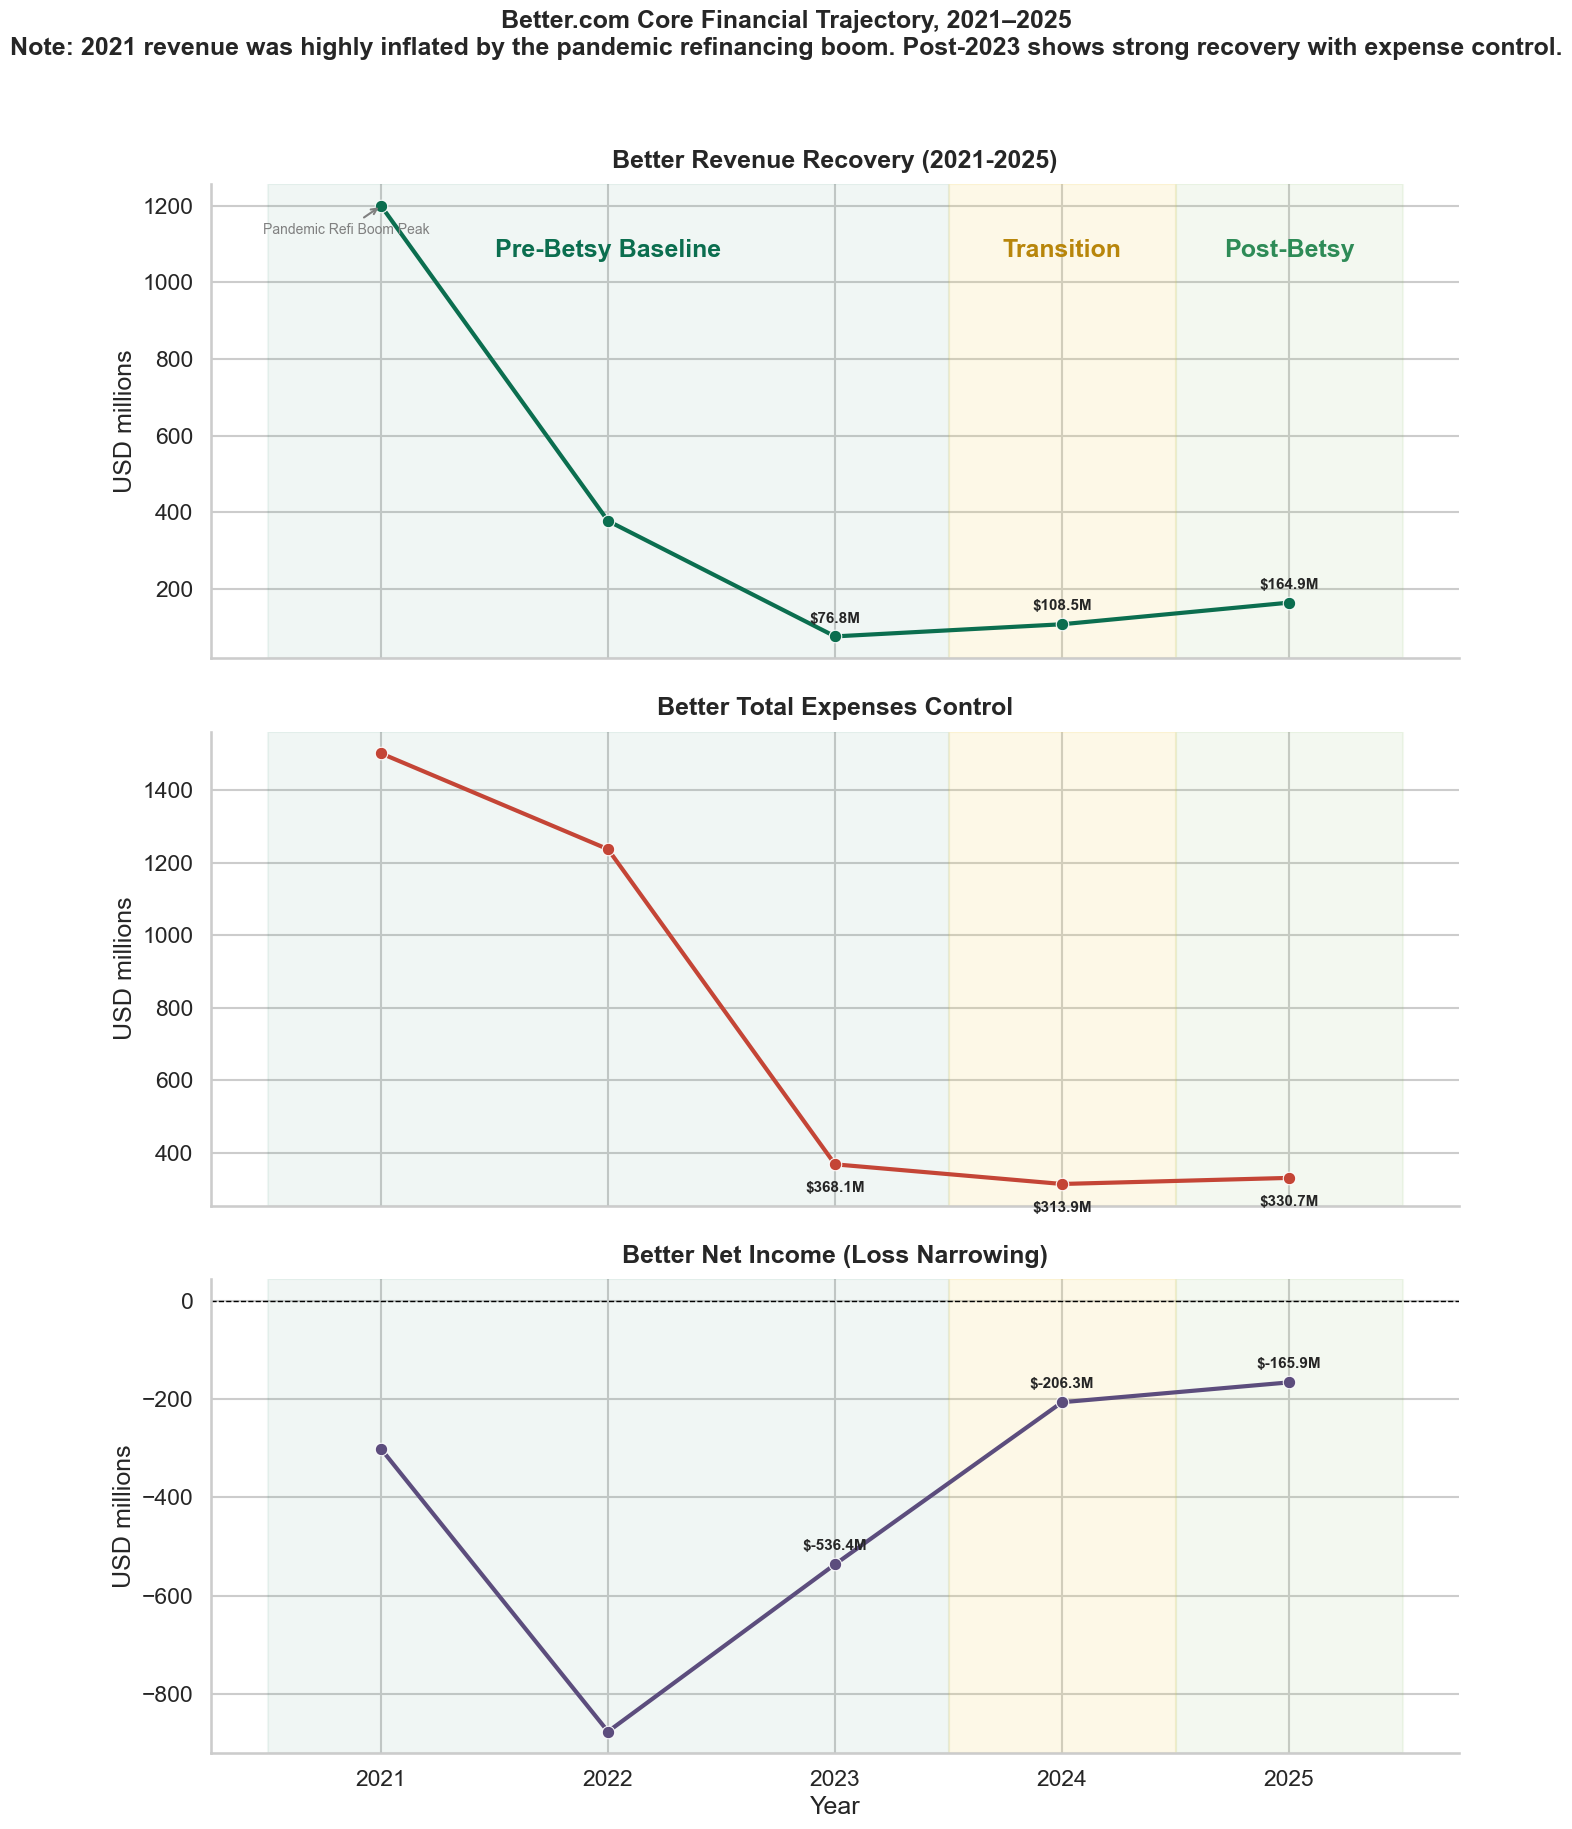

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

def add_full_shading_and_text(ax):
    ax.axvspan(2020.5, 2023.5, color=BETTER_COLOR, alpha=0.06)
    ax.axvspan(2023.5, 2024.5, color=TRANSITION_COLOR, alpha=0.15)
    ax.axvspan(2024.5, 2025.5, color=POST_COLOR, alpha=0.10)
    
    if ax == axes[0]:
        ax.text(2022.0, ax.get_ylim()[1] * 0.85, "Pre-Betsy Baseline", ha="center", weight="bold", color=BETTER_COLOR)
        ax.text(2024.0, ax.get_ylim()[1] * 0.85, "Transition", ha="center", weight="bold", color="#B8860B")
        ax.text(2025.0, ax.get_ylim()[1] * 0.85, "Post-Betsy", ha="center", weight="bold", color="#2E8B57")

# Subplot 0: Revenue
sns.lineplot(data=better, x="Year", y="Revenue", marker="o", color=BETTER_COLOR, linewidth=3, ax=axes[0])
add_full_shading_and_text(axes[0])
finish_axis(axes[0], "Better Revenue Recovery (2021-2025)", "USD millions", years=better["Year"])
for y in [2023, 2024, 2025]:
    val = better.loc[better["Year"] == y, "Revenue"].iloc[0]
    axes[0].annotate(f"${val:.1f}M", (y, val), textcoords="offset points", xytext=(0,10), ha="center", weight="bold", fontsize=11)
val_2021 = better.loc[better["Year"] == 2021, "Revenue"].iloc[0]
axes[0].annotate("Pandemic Refi Boom Peak", (2021, val_2021), textcoords="offset points", xytext=(-25,-20), ha="center", color="gray", fontsize=10, arrowprops=dict(arrowstyle="->", color="gray"))

# Subplot 1: Total Expenses
sns.lineplot(data=better, x="Year", y="Total_Expenses", marker="o", color="#C44536", linewidth=3, ax=axes[1])
add_full_shading_and_text(axes[1])
finish_axis(axes[1], "Better Total Expenses Control", "USD millions", years=better["Year"])
for y in [2023, 2024, 2025]:
    val = better.loc[better["Year"] == y, "Total_Expenses"].iloc[0]
    axes[1].annotate(f"${val:.1f}M", (y, val), textcoords="offset points", xytext=(0,-20), ha="center", weight="bold", fontsize=11)

# Subplot 2: Net Income
sns.lineplot(data=better, x="Year", y="Net_Income", marker="o", color="#5C4D7D", linewidth=3, ax=axes[2])
axes[2].axhline(0, color="black", linewidth=1, linestyle="--")
add_full_shading_and_text(axes[2])
finish_axis(axes[2], "Better Net Income (Loss Narrowing)", "USD millions", years=better["Year"])
for y in [2023, 2024, 2025]:
    val = better.loc[better["Year"] == y, "Net_Income"].iloc[0]
    axes[2].annotate(f"${val:.1f}M", (y, val), textcoords="offset points", xytext=(0,10), ha="center", weight="bold", fontsize=11)

fig.suptitle("Better.com Core Financial Trajectory, 2021–2025\n"
             "Note: 2021 revenue was highly inflated by the pandemic refinancing boom. Post-2023 shows strong recovery with expense control.", 
             fontsize=18, weight="bold", y=1.02)
plt.tight_layout()
save_figure(fig, "fig_fin_better_financial_trajectory_clean.png", OUTPUT_DIR, save=SAVE_FIGURES)
plt.show()

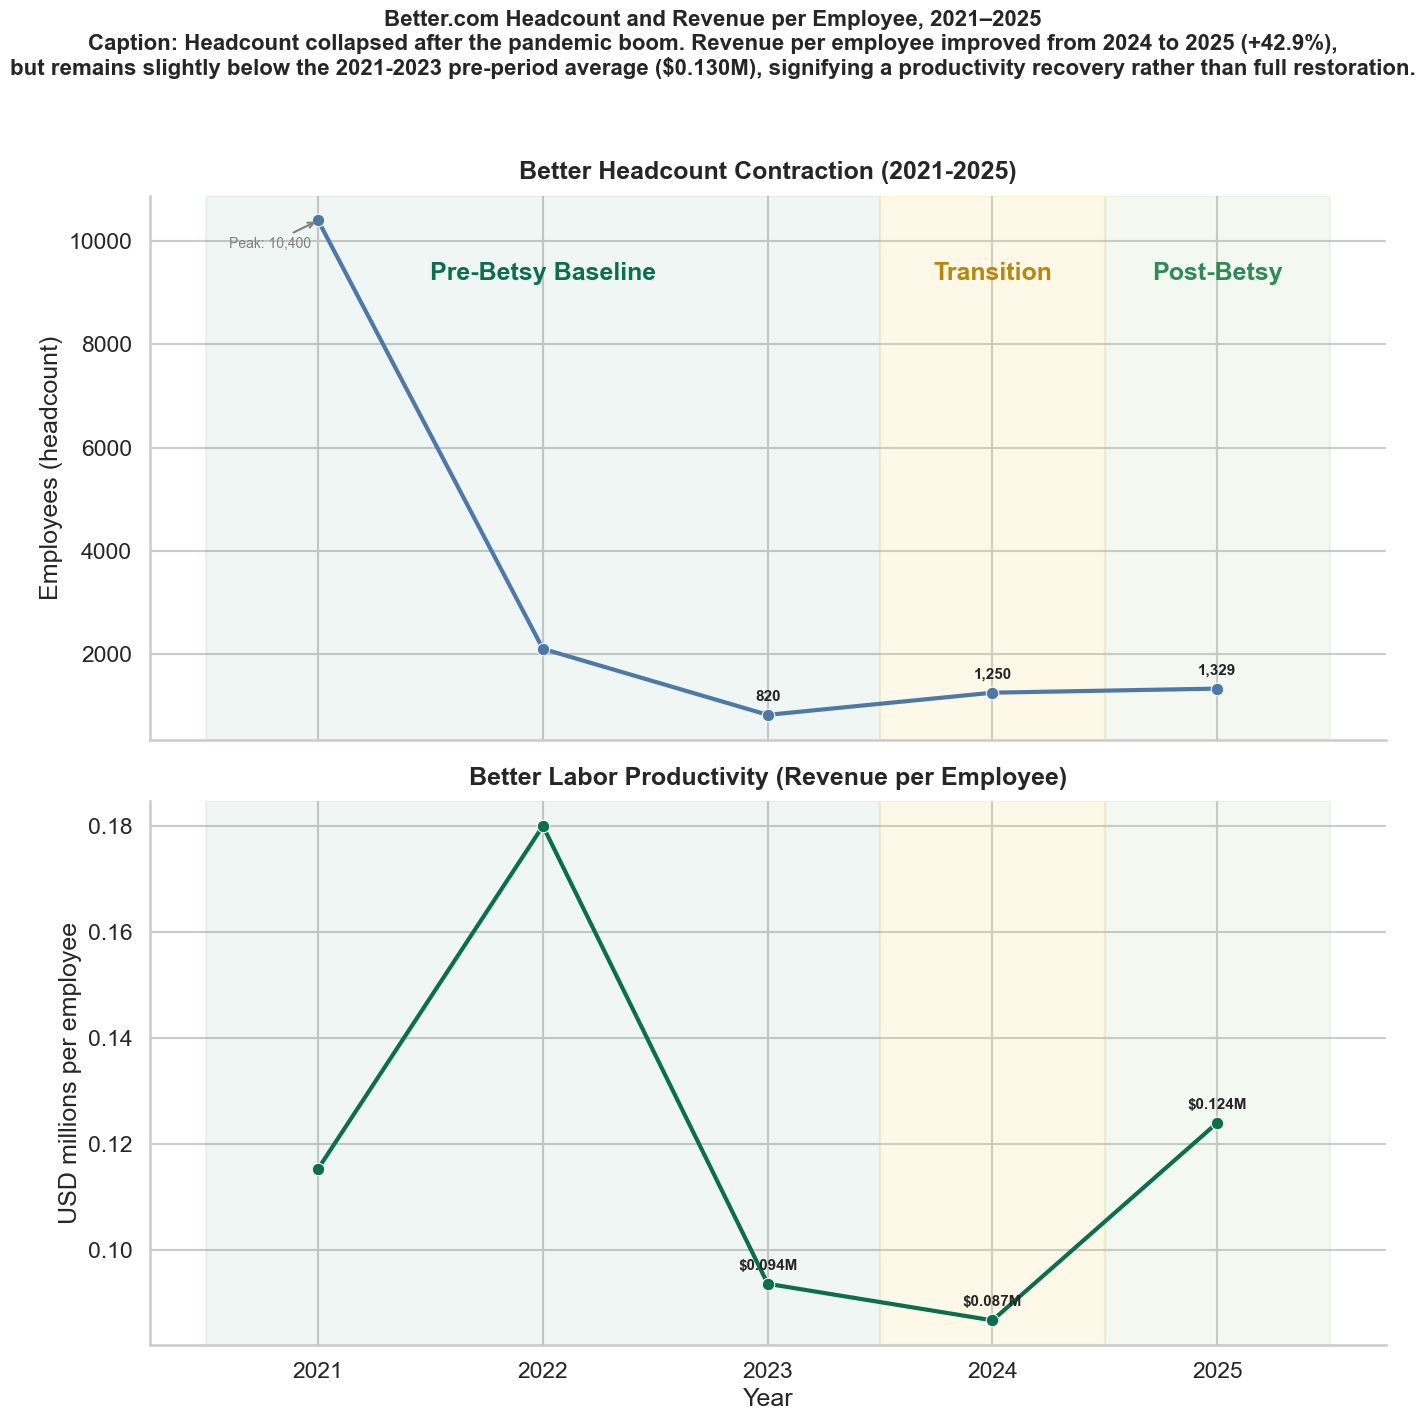

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 14), sharex=True)

def add_full_shading_and_text_headcount(ax):
    ax.axvspan(2020.5, 2023.5, color=BETTER_COLOR, alpha=0.06)
    ax.axvspan(2023.5, 2024.5, color=TRANSITION_COLOR, alpha=0.15)
    ax.axvspan(2024.5, 2025.5, color=POST_COLOR, alpha=0.10)
    
    if ax == axes[0]:
        ax.text(2022.0, ax.get_ylim()[1] * 0.85, "Pre-Betsy Baseline", ha="center", weight="bold", color=BETTER_COLOR)
        ax.text(2024.0, ax.get_ylim()[1] * 0.85, "Transition", ha="center", weight="bold", color="#B8860B")
        ax.text(2025.0, ax.get_ylim()[1] * 0.85, "Post-Betsy", ha="center", weight="bold", color="#2E8B57")

# Subplot 0: Headcount
sns.lineplot(data=better, x="Year", y="Employees", marker="o", color="#4E79A7", linewidth=3, ax=axes[0])
add_full_shading_and_text_headcount(axes[0])
finish_axis(axes[0], "Better Headcount Contraction (2021-2025)", "Employees (headcount)", years=better["Year"])
for y in [2023, 2024, 2025]:
    val = int(better.loc[better["Year"] == y, "Employees"].iloc[0])
    axes[0].annotate(f"{val:,}", (y, val), textcoords="offset points", xytext=(0,10), ha="center", weight="bold", fontsize=11)
peak_val = int(better.loc[better["Year"] == 2021, "Employees"].iloc[0])
axes[0].annotate(f"Peak: {peak_val:,}", (2021, peak_val), textcoords="offset points", xytext=(-35,-20), ha="center", color="gray", fontsize=10, arrowprops=dict(arrowstyle="->", color="gray"))

# Subplot 1: Revenue per Employee
sns.lineplot(data=better, x="Year", y="Revenue_per_Employee", marker="o", color=BETTER_COLOR, linewidth=3, ax=axes[1])
add_full_shading_and_text_headcount(axes[1])
finish_axis(axes[1], "Better Labor Productivity (Revenue per Employee)", "USD millions per employee", years=better["Year"])
for y in [2023, 2024, 2025]:
    val = better.loc[better["Year"] == y, "Revenue_per_Employee"].iloc[0]
    axes[1].annotate(f"${val:.3f}M", (y, val), textcoords="offset points", xytext=(0,10), ha="center", weight="bold", fontsize=11)

fig.suptitle("Better.com Headcount and Revenue per Employee, 2021–2025\n"
             "Caption: Headcount collapsed after the pandemic boom. Revenue per employee improved from 2024 to 2025 (+42.9%),\n"
             "but remains slightly below the 2021-2023 pre-period average ($0.130M), signifying a productivity recovery rather than full restoration.", 
             fontsize=16, weight="bold", y=1.02)
plt.tight_layout()
save_figure(fig, "fig_fin_headcount_productivity_clean.png", OUTPUT_DIR, save=SAVE_FIGURES)
plt.show()

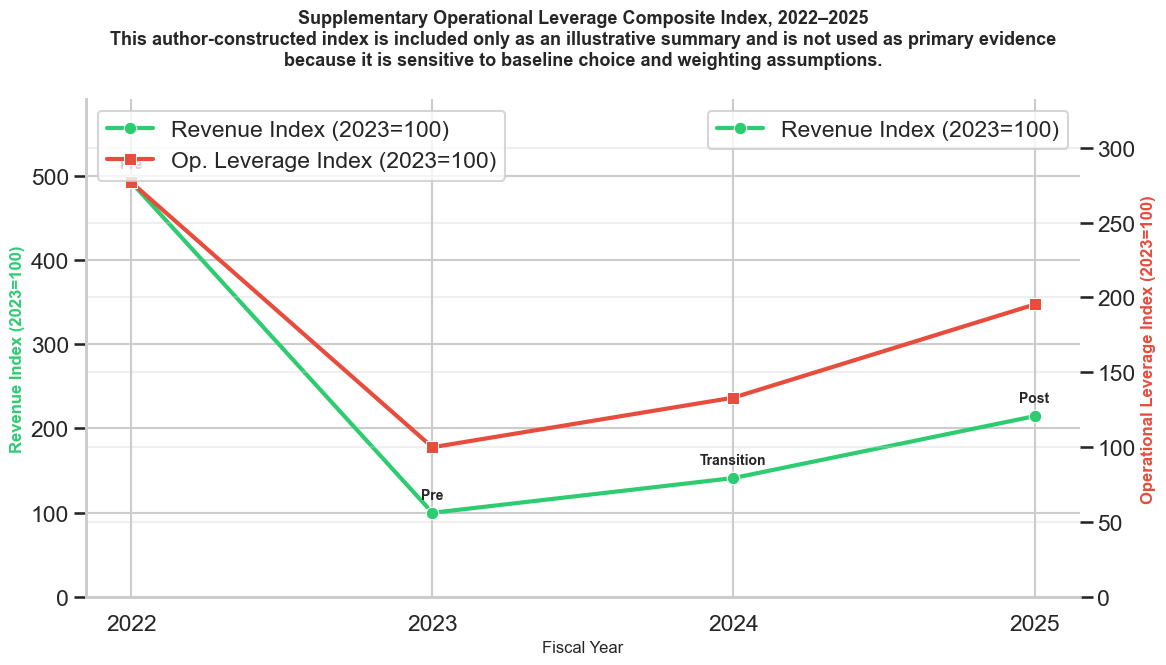

In [7]:
fig = plt.figure(figsize=(12, 7))

plot_data = better[better['Year'] >= 2022].copy()
plot_data['Year_Str'] = plot_data['Year'].astype(str)

ax1 = plt.gca()
sns.lineplot(data=plot_data, x='Year_Str', y='Revenue_Index_2023', label='Revenue Index (2023=100)', 
             marker='o', color='#2ecc71', linewidth=3, ax=ax1)

ax2 = ax1.twinx()
sns.lineplot(data=plot_data, x='Year_Str', y='Operational_Leverage_Index_2023', label='Op. Leverage Index (2023=100)', 
             marker='s', color='#e74c3c', linewidth=3, ax=ax2)

ax1.set_ylabel('Revenue Index (2023=100)', color='#2ecc71', fontsize=12, fontweight='bold')
ax2.set_ylabel('Operational Leverage Index (2023=100)', color='#e74c3c', fontsize=12, fontweight='bold')

ax1.set_ylim(0, max(plot_data['Revenue_Index_2023']) * 1.2)
ax2.set_ylim(0, max(plot_data['Operational_Leverage_Index_2023']) * 1.2)

plt.title('Supplementary Operational Leverage Composite Index, 2022–2025\n'
          'This author-constructed index is included only as an illustrative summary and is not used as primary evidence\n'
          'because it is sensitive to baseline choice and weighting assumptions.', fontsize=13, fontweight='bold', pad=25)
ax1.set_xlabel('Fiscal Year', fontsize=12)

for i, row in plot_data.iterrows():
    ax1.annotate(row['Period'], (str(row['Year']), row['Revenue_Index_2023']), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.grid(True, alpha=0.3)
plt.tight_layout()
save_figure(fig, "appendix_fig_fin_operational_leverage_index.png", OUTPUT_DIR, save=SAVE_FIGURES)
plt.show()

## 4. Better vs Rocket benchmark comparison

Rocket is used here as an incumbent mortgage benchmark with a mature scale-based operating model. This is a contextual comparison, not a formal control-group design.

Important caveat: Rocket's 2025 values should be interpreted carefully because the thesis documentation notes acquisition-related scale effects that may distort strict comparability, especially for employee-based ratios.


In [8]:
comparison_table = common_window[
    [
        "Company",
        "Year",
        "Revenue",
        "Total_Expenses",
        "Net_Income",
        "Employees",
        "Revenue_per_Employee",
        "Expense_Ratio",
        "Profit_Margin",
        "Cash_Flow_Margin",
        "Equity_Ratio",
    ]
]

display(
    comparison_table.style.format(
        {
            "Revenue": "{:,.3f}",
            "Total_Expenses": "{:,.3f}",
            "Net_Income": "{:,.3f}",
            "Employees": "{:,.0f}",
            "Revenue_per_Employee": "{:,.3f}",
            "Expense_Ratio": "{:,.2f}",
            "Profit_Margin": "{:.1%}",
            "Cash_Flow_Margin": "{:.1%}",
            "Equity_Ratio": "{:.1%}",
        }
    )
)


,Company,Year,Revenue,Total_Expenses,Net_Income,Employees,Revenue_per_Employee,Expense_Ratio,Profit_Margin,Cash_Flow_Margin,Equity_Ratio
0,Better,2021,"1,200.000","1,501.300",-301.300,"10,400",0.115,1.25,-25.1%,-20.8%,21.8%
1,Better,2022,378.023,"1,236.943",-877.077,"2,100",0.180,3.27,-232.0%,248.2%,-55.8%
2,Better,2023,76.820,368.096,-536.420,820,0.094,4.79,-698.3%,-207.9%,13.5%
3,Better,2024,108.488,313.928,-206.290,"1,250",0.087,2.89,-190.2%,-350.2%,-6.4%
4,Better,2025,164.872,330.691,-165.872,"1,329",0.124,2.01,-100.6%,-101.0%,2.5%
8,Rocket,2021,"12,914.466","6,729.565","6,072.163","26,000",0.497,0.52,47.0%,60.0%,29.8%
9,Rocket,2022,"5,838.493","5,096.582",699.933,"18,500",0.316,0.87,12.0%,185.4%,42.2%
10,Rocket,2023,"3,799.269","4,202.166",-390.080,"14,700",0.258,1.11,-10.3%,2.9%,43.2%
11,Rocket,2024,"5,100.798","4,433.000",635.828,"14,200",0.359,0.87,12.5%,-51.5%,36.9%
12,Rocket,2025,"6,695.000","6,909.000",-234.000,"23,500",0.285,1.03,-3.5%,-58.7%,37.7%


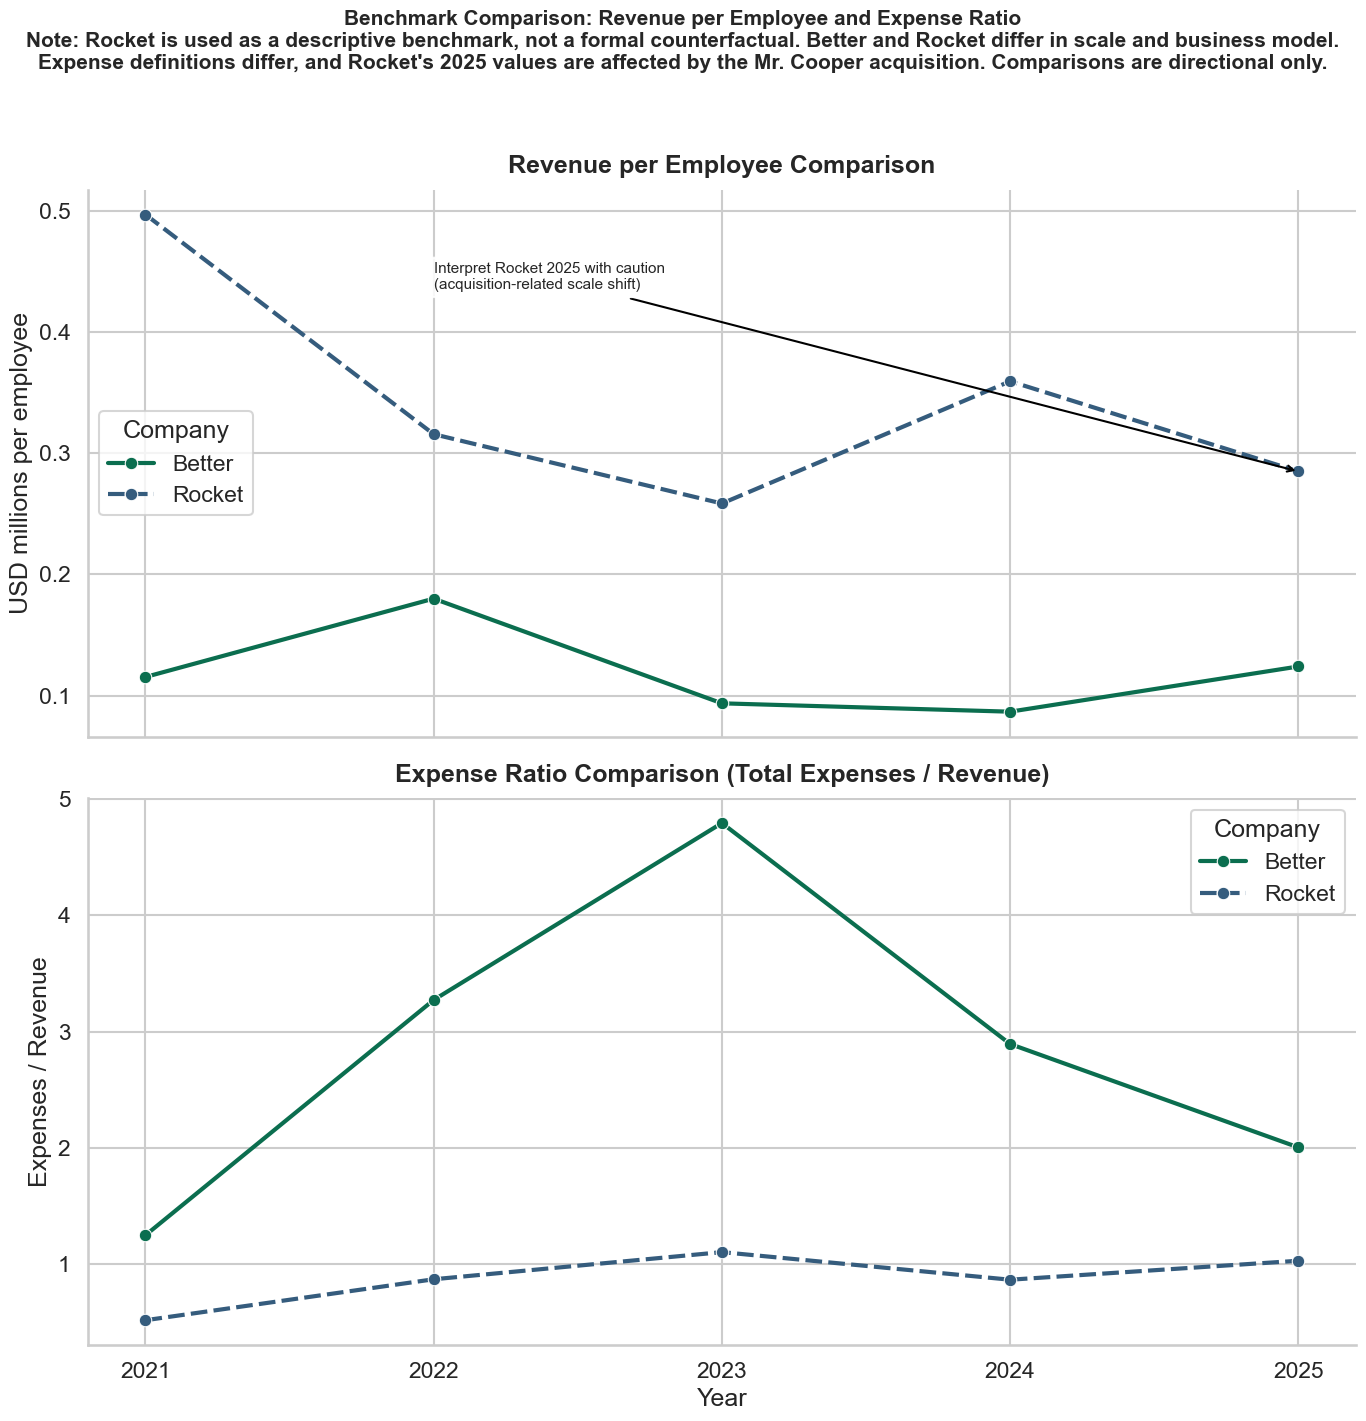

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 14), sharex=True)

sns.lineplot(
    data=common_window,
    x="Year",
    y="Revenue_per_Employee",
    hue="Company",
    style="Company",
    marker="o",
    linewidth=3,
    palette={"Better": BETTER_COLOR, "Rocket": ROCKET_COLOR},
    ax=axes[0],
)
finish_axis(axes[0], "Revenue per Employee Comparison", "USD millions per employee", years=common_window["Year"])

sns.lineplot(
    data=common_window,
    x="Year",
    y="Expense_Ratio",
    hue="Company",
    style="Company",
    marker="o",
    linewidth=3,
    palette={"Better": BETTER_COLOR, "Rocket": ROCKET_COLOR},
    ax=axes[1],
)
finish_axis(axes[1], "Expense Ratio Comparison (Total Expenses / Revenue)", "Expenses / Revenue", years=common_window["Year"])

rocket_2025 = rocket.loc[rocket["Year"] == 2025, "Revenue_per_Employee"]
if not rocket_2025.empty:
    axes[0].annotate(
        "Interpret Rocket 2025 with caution\n(acquisition-related scale shift)",
        xy=(2025, rocket_2025.iloc[0]),
        xytext=(2022.0, rocket_2025.iloc[0] + 0.15),
        arrowprops={"arrowstyle": "->", "color": "black"},
        fontsize=11,
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.85},
    )

fig.suptitle("Benchmark Comparison: Revenue per Employee and Expense Ratio\n"
             "Note: Rocket is used as a descriptive benchmark, not a formal counterfactual. Better and Rocket differ in scale and business model.\n"
             "Expense definitions differ, and Rocket's 2025 values are affected by the Mr. Cooper acquisition. Comparisons are directional only.", 
             fontsize=15, weight="bold", y=1.02)
plt.tight_layout()
save_figure(fig, "fig_fin_benchmark_productivity_expense_ratio_clean.png", OUTPUT_DIR, save=SAVE_FIGURES)
plt.show()

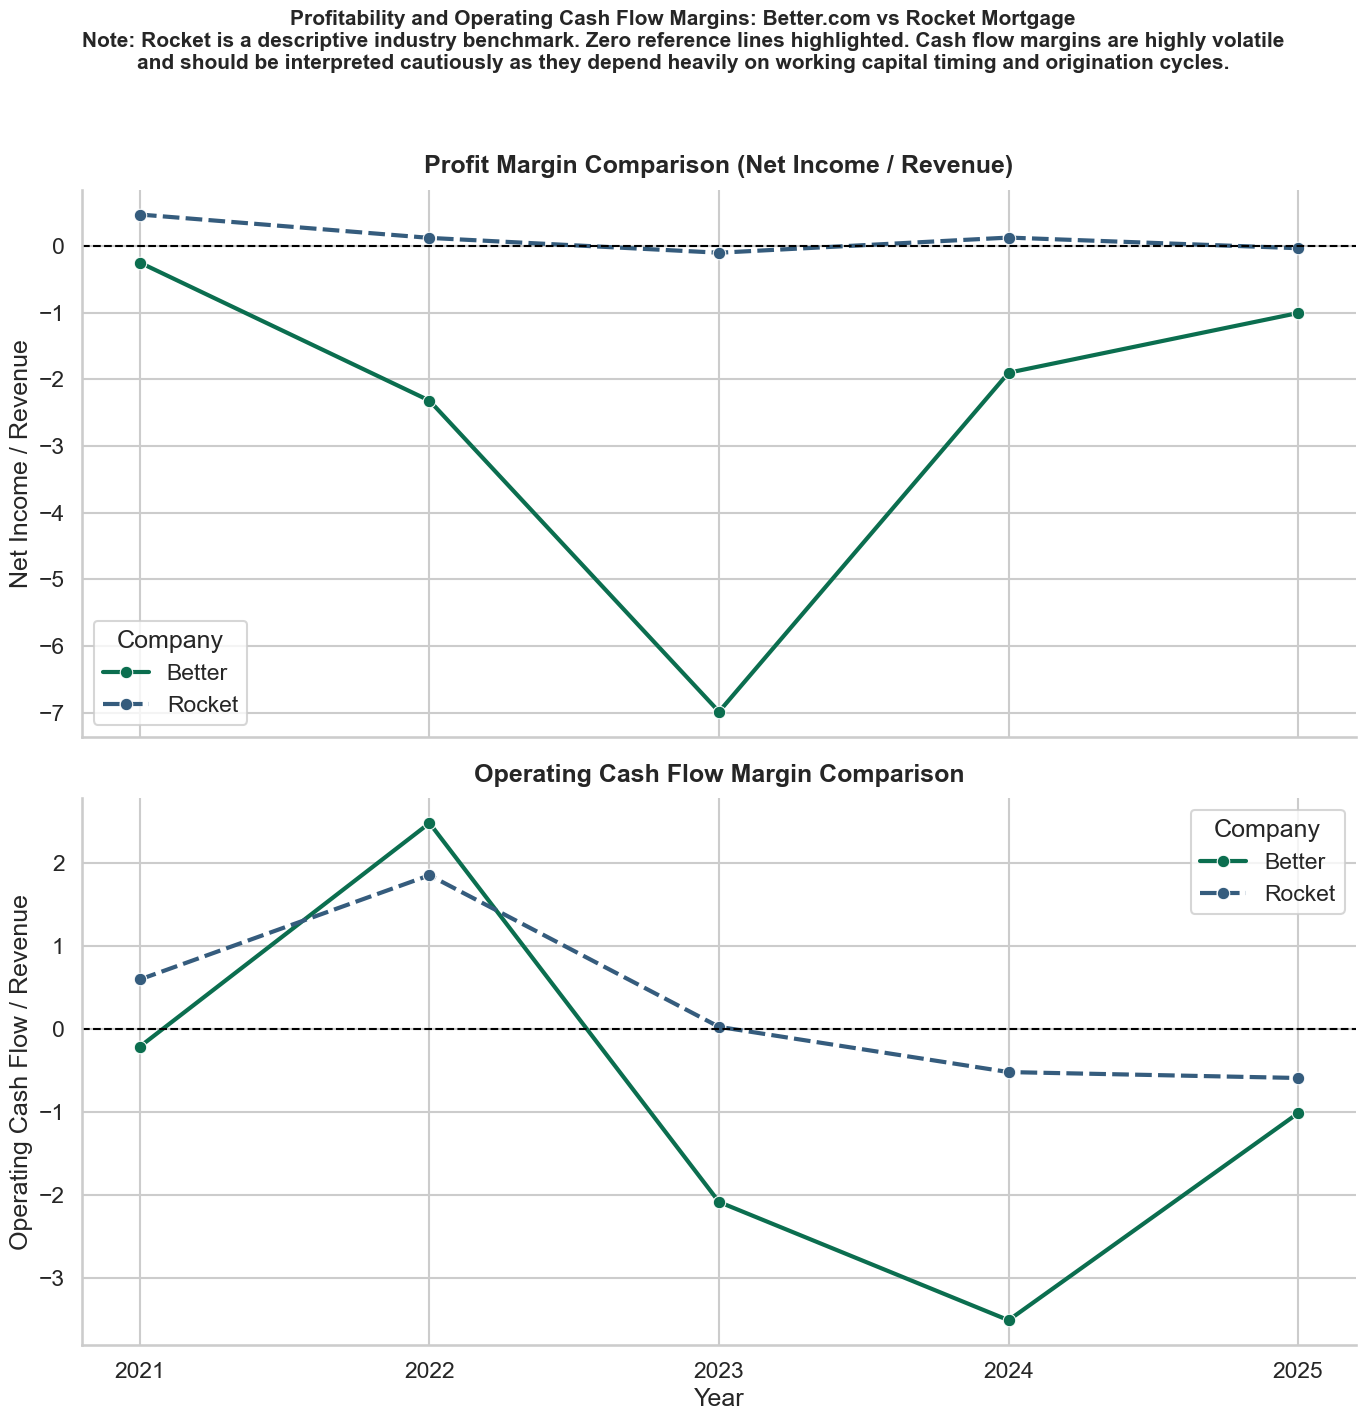

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 14), sharex=True)

sns.lineplot(
    data=common_window,
    x="Year",
    y="Profit_Margin",
    hue="Company",
    style="Company",
    marker="o",
    linewidth=3,
    palette={"Better": BETTER_COLOR, "Rocket": ROCKET_COLOR},
    ax=axes[0],
)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1.5)
finish_axis(axes[0], "Profit Margin Comparison (Net Income / Revenue)", "Net Income / Revenue", years=common_window["Year"])

sns.lineplot(
    data=common_window,
    x="Year",
    y="Cash_Flow_Margin",
    hue="Company",
    style="Company",
    marker="o",
    linewidth=3,
    palette={"Better": BETTER_COLOR, "Rocket": ROCKET_COLOR},
    ax=axes[1],
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1.5)
finish_axis(axes[1], "Operating Cash Flow Margin Comparison", "Operating Cash Flow / Revenue", years=common_window["Year"])

fig.suptitle("Profitability and Operating Cash Flow Margins: Better.com vs Rocket Mortgage\n"
             "Note: Rocket is a descriptive industry benchmark. Zero reference lines highlighted. Cash flow margins are highly volatile\n"
             "and should be interpreted cautiously as they depend heavily on working capital timing and origination cycles.", 
             fontsize=15, weight="bold", y=1.02)
plt.tight_layout()
save_figure(fig, "fig_fin_profitability_cashflow_benchmark_clean.png", OUTPUT_DIR, save=SAVE_FIGURES)
plt.show()

## 5. Light pre-transition-post comparison

Because the sample is very small, the notebook avoids regression, prediction, or machine learning. Instead it uses descriptive period summaries and a light difference-of-changes table to show whether Better's post-period moved in a direction consistent with operational leverage.


In [11]:
metrics_for_periods = [
    "Revenue",
    "Total_Expenses",
    "Net_Income",
    "Employees",
    "Revenue_per_Employee",
    "Expense_per_Employee",
    "Expense_Ratio",
    "Profit_Margin",
    "Cash_Flow_Margin",
]

better_pre_avg = better.loc[better["Period"] == "Pre", metrics_for_periods].mean()
better_transition = better.loc[better["Period"] == "Transition", metrics_for_periods].iloc[0]
better_post = better.loc[better["Period"] == "Post", metrics_for_periods].iloc[0]

period_summary = pd.DataFrame(
    {
        "Pre_Average_2021_2023": better_pre_avg,
        "Transition_2024": better_transition,
        "Post_2025": better_post,
        "Post_vs_Pre_Absolute_Change": better_post - better_pre_avg,
        "Post_vs_Pre_%_Change": (better_post / better_pre_avg) - 1,
    }
)

display(period_summary.round(3))

common_pre_years = [2021, 2022, 2023]
did_metrics = ["Revenue", "Total_Expenses", "Revenue_per_Employee", "Expense_Ratio", "Profit_Margin"]

better_pre_common = common_window[(common_window["Company"] == "Better") & (common_window["Year"].isin(common_pre_years))][did_metrics].mean()
rocket_pre_common = common_window[(common_window["Company"] == "Rocket") & (common_window["Year"].isin(common_pre_years))][did_metrics].mean()
better_post_2025 = common_window[(common_window["Company"] == "Better") & (common_window["Year"] == 2025)][did_metrics].iloc[0]
rocket_post_2025 = common_window[(common_window["Company"] == "Rocket") & (common_window["Year"] == 2025)][did_metrics].iloc[0]

did_table = pd.DataFrame(
    {
        "Better_Pre_Avg": better_pre_common,
        "Better_Post_2025": better_post_2025,
        "Better_Change": better_post_2025 - better_pre_common,
        "Rocket_Pre_Avg": rocket_pre_common,
        "Rocket_Post_2025": rocket_post_2025,
        "Rocket_Change": rocket_post_2025 - rocket_pre_common,
    }
)
did_table["Descriptive_Diff_of_Changes"] = did_table["Better_Change"] - did_table["Rocket_Change"]

display(did_table.round(3))


,Pre_Average_2021_2023,Transition_2024,Post_2025,Post_vs_Pre_Absolute_Change,Post_vs_Pre_%_Change
Revenue,551.614,108.488,164.872,-386.742,-0.701
Total_Expenses,"1,035.446",313.928,330.691,-704.755,-0.681
Net_Income,-571.599,-206.290,-165.872,405.727,-0.710
Employees,"4,440.000","1,250.000","1,329.000","-3,111.000",-0.701
Revenue_per_Employee,0.130,0.087,0.124,-0.006,-0.043
Expense_per_Employee,0.394,0.251,0.249,-0.145,-0.369
Expense_Ratio,3.105,2.894,2.006,-1.099,-0.354
Profit_Margin,-3.185,-1.902,-1.006,2.179,-0.684
Cash_Flow_Margin,0.065,-3.502,-1.010,-1.075,-16.582


,Better_Pre_Avg,Better_Post_2025,Better_Change,Rocket_Pre_Avg,Rocket_Post_2025,Rocket_Change,Descriptive_Diff_of_Changes
Revenue,551.614,164.872,-386.742,"7,517.409","6,695.000",-822.409,435.667
Total_Expenses,"1,035.446",330.691,-704.755,"5,342.771","6,909.000","1,566.229","-2,270.984"
Revenue_per_Employee,0.130,0.124,-0.006,0.357,0.285,-0.072,0.066
Expense_Ratio,3.105,2.006,-1.099,0.833,1.032,0.199,-1.298
Profit_Margin,-3.185,-1.006,2.179,0.162,-0.035,-0.197,2.376


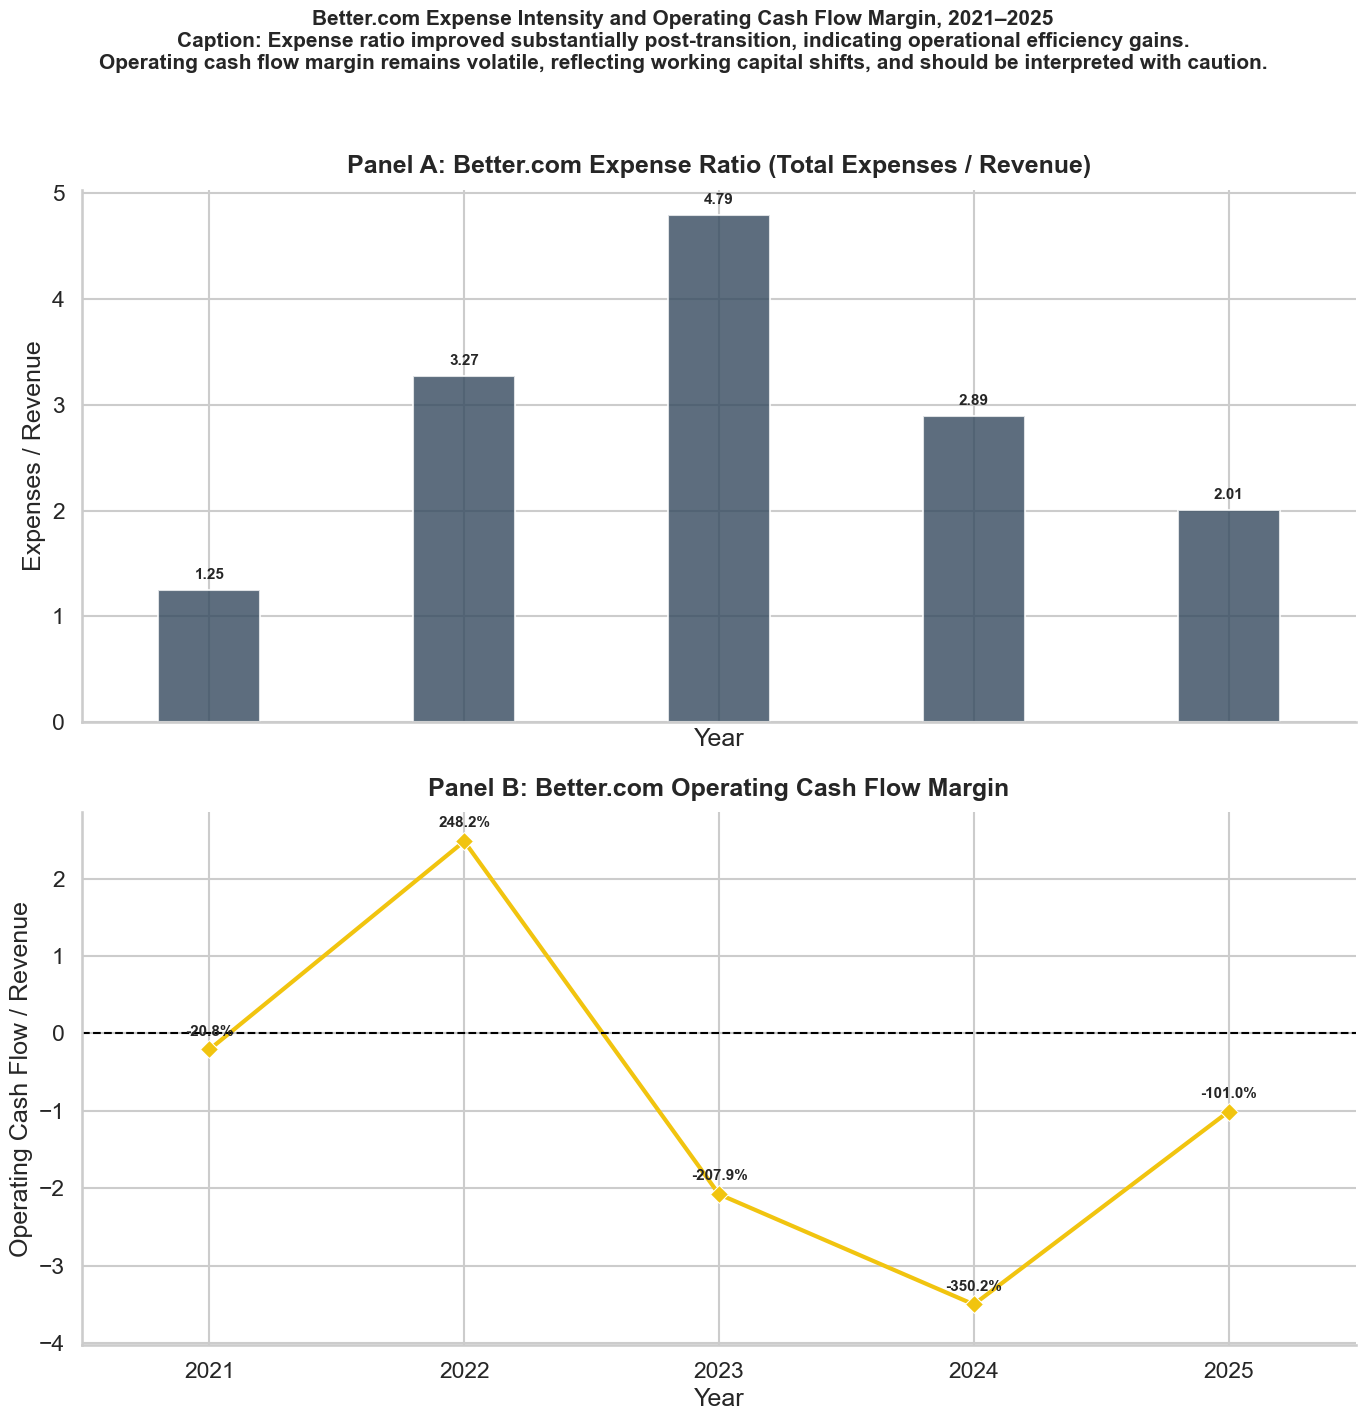

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 14), sharex=True)

plot_data = better[better['Year'] >= 2021].copy()

# Panel A: Expense Ratio (Using Matplotlib's native bar plot to maintain numeric x-axis alignment)
axes[0].bar(plot_data['Year'], plot_data['Expense_Ratio'], color='#34495e', alpha=0.8, width=0.4)
finish_axis(axes[0], "Panel A: Better.com Expense Ratio (Total Expenses / Revenue)", "Expenses / Revenue", years=plot_data["Year"])
for row in plot_data.itertuples():
    axes[0].text(row.Year, row.Expense_Ratio + 0.1, f"{row.Expense_Ratio:.2f}", ha="center", weight="bold", fontsize=11)

# Panel B: Operating Cash Flow Margin
sns.lineplot(data=plot_data, x='Year', y='Cash_Flow_Margin', color='#f1c40f', marker='D', linewidth=3, ax=axes[1])
axes[1].axhline(0, color="black", linestyle="--", linewidth=1.5)
finish_axis(axes[1], "Panel B: Better.com Operating Cash Flow Margin", "Operating Cash Flow / Revenue", years=plot_data["Year"])
axes[1].set_ylim(min(plot_data['Cash_Flow_Margin']) * 1.15, max(plot_data['Cash_Flow_Margin']) * 1.15)
for row in plot_data.itertuples():
    axes[1].annotate(f"{row.Cash_Flow_Margin:.1%}", (row.Year, row.Cash_Flow_Margin), textcoords="offset points", xytext=(0,10), ha="center", weight="bold", fontsize=11)

# Set the shared x-limits to perfectly frame the years with a margin
axes[1].set_xlim(2020.5, 2025.5)

fig.suptitle("Better.com Expense Intensity and Operating Cash Flow Margin, 2021–2025\n"
             "Caption: Expense ratio improved substantially post-transition, indicating operational efficiency gains.\n"
             "Operating cash flow margin remains volatile, reflecting working capital shifts, and should be interpreted with caution.", 
             fontsize=15, weight="bold", y=1.02)
plt.tight_layout()
save_figure(fig, "fig_fin_expense_ratio_cashflow_clean.png", OUTPUT_DIR, save=SAVE_FIGURES)
plt.show()

## 6. RQ2-oriented findings summary

The final cell converts the descriptive evidence into thesis-ready findings language. The emphasis remains on directional consistency with operational leverage, not causal proof.


In [13]:
revenue_2023 = better.loc[better["Year"] == 2023, "Revenue"].iloc[0]
revenue_2025 = better.loc[better["Year"] == 2025, "Revenue"].iloc[0]
expenses_2023 = better.loc[better["Year"] == 2023, "Total_Expenses"].iloc[0]
expenses_2025 = better.loc[better["Year"] == 2025, "Total_Expenses"].iloc[0]
loss_2023 = abs(better.loc[better["Year"] == 2023, "Net_Income"].iloc[0])
loss_2025 = abs(better.loc[better["Year"] == 2025, "Net_Income"].iloc[0])
rpe_2023 = better.loc[better["Year"] == 2023, "Revenue_per_Employee"].iloc[0]
rpe_2025 = better.loc[better["Year"] == 2025, "Revenue_per_Employee"].iloc[0]
expense_ratio_2023 = better.loc[better["Year"] == 2023, "Expense_Ratio"].iloc[0]
expense_ratio_2025 = better.loc[better["Year"] == 2025, "Expense_Ratio"].iloc[0]
oli_2025 = better.loc[better["Year"] == 2025, "Operational_Leverage_Index_2023"].iloc[0]

findings_md = f"""
### Empirical findings for RQ2

- **Revenue recovery:** Better's revenue increased from **${revenue_2023:,.1f}M** in 2023 to **${revenue_2025:,.1f}M** in 2025, a change of **{((revenue_2025 / revenue_2023) - 1):.1%}**.
- **Controlled expense growth:** Over the same 2023-2025 window, total expenses changed from **${expenses_2023:,.1f}M** to **${expenses_2025:,.1f}M**, which is materially slower than revenue growth and therefore directionally consistent with operating leverage.
- **Narrowing losses:** Net losses improved from **-${loss_2023:,.1f}M** in 2023 to **-${loss_2025:,.1f}M** in 2025, a loss reduction of **{(1 - loss_2025 / loss_2023):.1%}**.
- **Improved labor productivity:** Revenue per employee increased from **${rpe_2023:,.3f}M** to **${rpe_2025:,.3f}M**, a gain of **{((rpe_2025 / rpe_2023) - 1):.1%}**.
- **Lower expense intensity:** Better's expense ratio declined from **{expense_ratio_2023:,.2f}** in 2023 to **{expense_ratio_2025:,.2f}** in 2025, indicating that revenue recovery was not matched by proportional expense growth.
- **Composite directional signal (Appendix):** The custom equally-weighted operational leverage index rises to **{oli_2025:,.1f}** by 2025 with **2023 = 100**, indicating simultaneous improvement in recovery, productivity, and cost intensity. This is retained only as a supplementary appendix visual.

### Thesis-ready interpretation

The dataset does **not** allow causal proof that Betsy directly caused Better's improvement. However, Better's post-implementation period in 2025 shows stronger revenue recovery, lower expense intensity, improved revenue per employee, and narrower losses. Taken together, these patterns are **consistent with AI-enabled operational leverage** and therefore provide disciplined empirical support for the thesis argument in `RQ2`.
"""

display(Markdown(findings_md))


### Empirical findings for RQ2

- **Revenue recovery:** Better's revenue increased from **$76.8M** in 2023 to **$164.9M** in 2025, a change of **114.6%**.
- **Controlled expense growth:** Over the same 2023-2025 window, total expenses changed from **$368.1M** to **$330.7M**, which is materially slower than revenue growth and therefore directionally consistent with operating leverage.
- **Narrowing losses:** Net losses improved from **-$536.4M** in 2023 to **-$165.9M** in 2025, a loss reduction of **69.1%**.
- **Improved labor productivity:** Revenue per employee increased from **$0.094M** to **$0.124M**, a gain of **32.4%**.
- **Lower expense intensity:** Better's expense ratio declined from **4.79** in 2023 to **2.01** in 2025, indicating that revenue recovery was not matched by proportional expense growth.
- **Composite directional signal (Appendix):** The custom equally-weighted operational leverage index rises to **195.3** by 2025 with **2023 = 100**, indicating simultaneous improvement in recovery, productivity, and cost intensity. This is retained only as a supplementary appendix visual.

### Thesis-ready interpretation

The dataset does **not** allow causal proof that Betsy directly caused Better's improvement. However, Better's post-implementation period in 2025 shows stronger revenue recovery, lower expense intensity, improved revenue per employee, and narrower losses. Taken together, these patterns are **consistent with AI-enabled operational leverage** and therefore provide disciplined empirical support for the thesis argument in `RQ2`.


## 7. Limitations and interpretation boundaries

This notebook should be interpreted alongside the methodological limitations already discussed in the thesis:

- The dataset is annual and very small, so inference must remain descriptive.
- SEC data is firm-level, not AI-level. It cannot isolate Betsy's direct contribution.
- `2024` is a mixed year because the launch occurred late in the year.
- Rocket is a benchmark, not a formal counterfactual.
- Customer-experience claims such as `NPS`, conversion improvement, call volumes, and automation rates require supplemental management-disclosure evidence rather than this CSV alone.

As a result, the notebook is best used as a **transparent empirical support layer** for the thesis argument, especially for the financial-performance and operational-efficiency dimensions of `RQ2`.
